In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

In [5]:
# import pandas as pd

# # URL for the Adult Income dataset
# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

# # Column names as per the dataset description
# column_names = [
#     'age', 'workclass', 'fnlwgt', 'education', 'education_num', 
#     'marital_status', 'occupation', 'relationship', 'race', 'sex',
#     'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
# ]

# # Load from URL
# df = pd.read_csv(url, header=None, names=column_names, na_values=' ?')

# # Save locally as CSV
# df.to_csv('adult_income.csv', index=False)
# print("✅ Dataset downloaded and saved as 'adult_income.csv'")

✅ Dataset downloaded and saved as 'adult_income.csv'


In [6]:
df = pd.read_csv('adult_income.csv')
print(f"✅ Loaded dataset with shape: {df.shape}")
df.head()


✅ Loaded dataset with shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Rows: 32561, Columns: 15
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


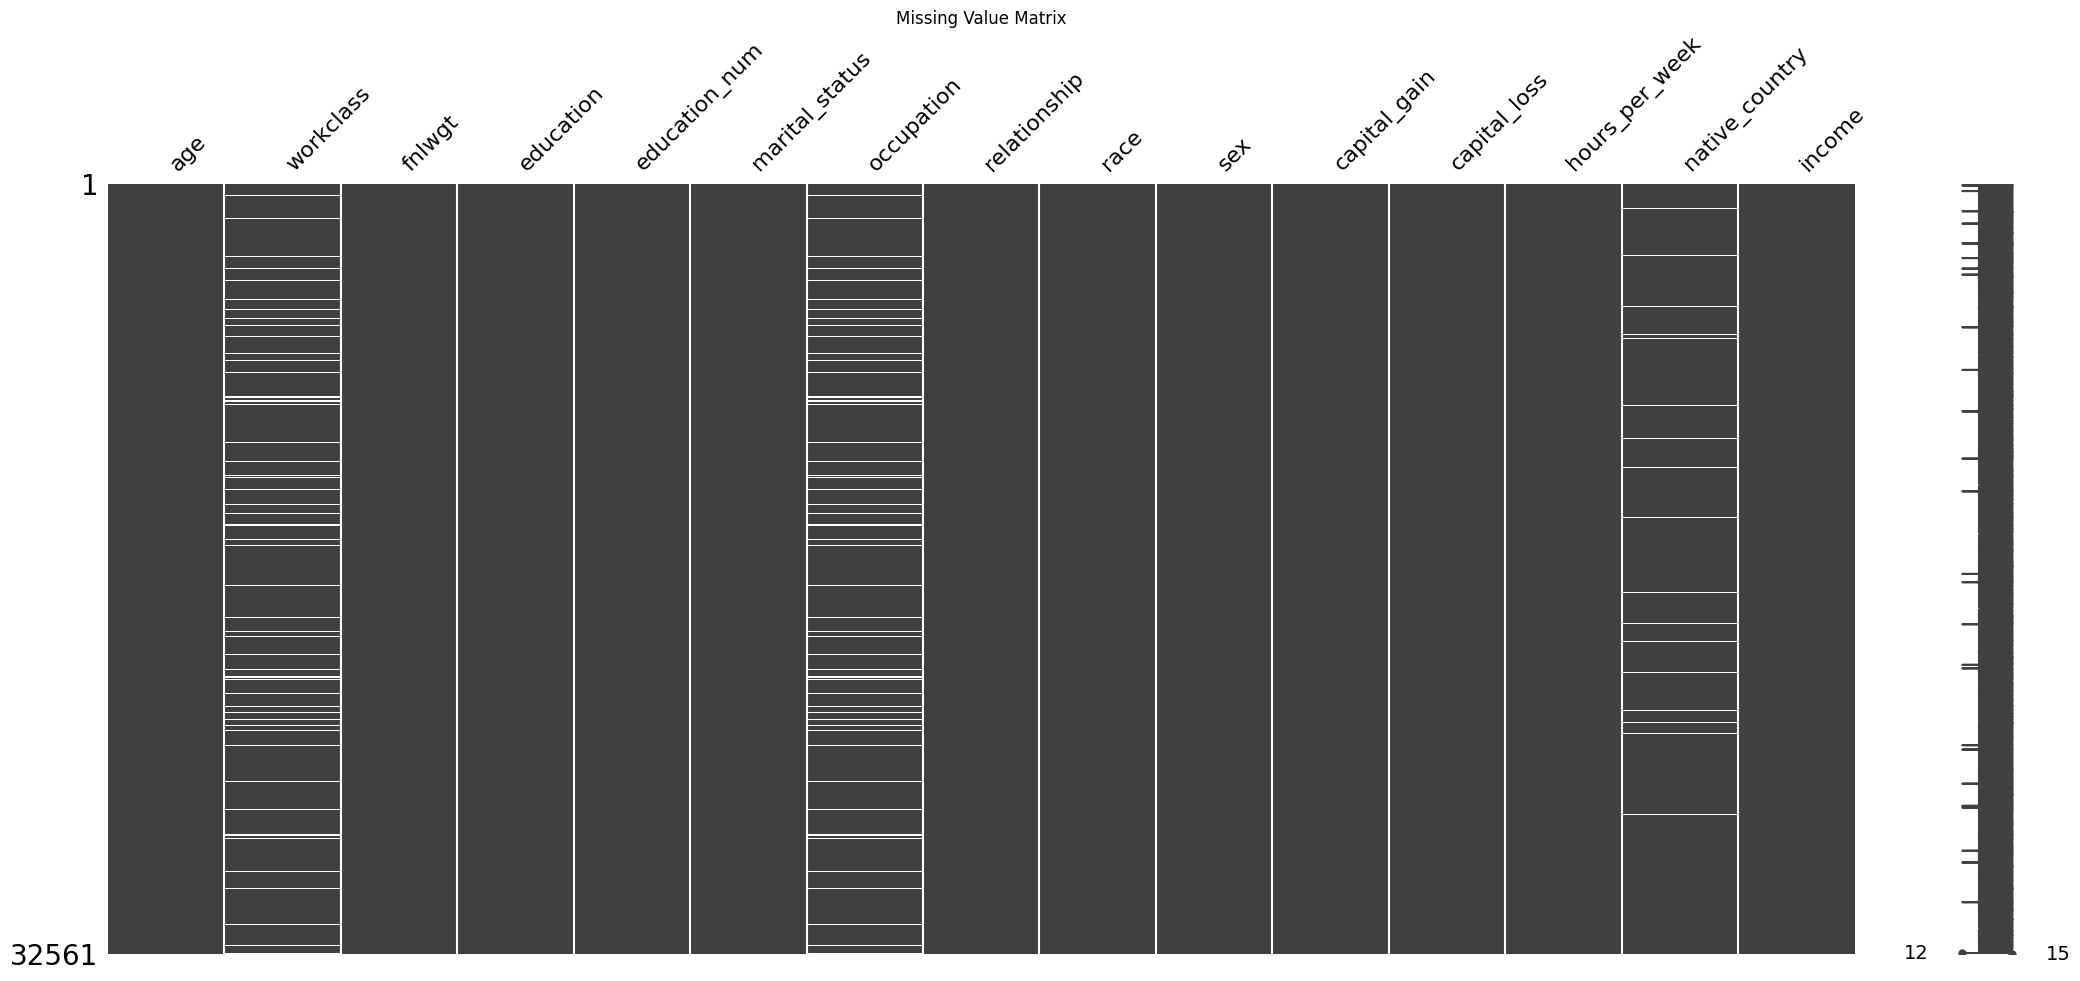

✅ Dropped missing values. New shape: (30162, 15)


In [7]:
# Shape and column info
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

# Summary statistics for numerical columns
df.describe()

# Count of missing values
df.isnull().sum()

# Visualize missing values
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

# Drop or impute missing values
df = df.dropna()
print(f"✅ Dropped missing values. New shape: {df.shape}")


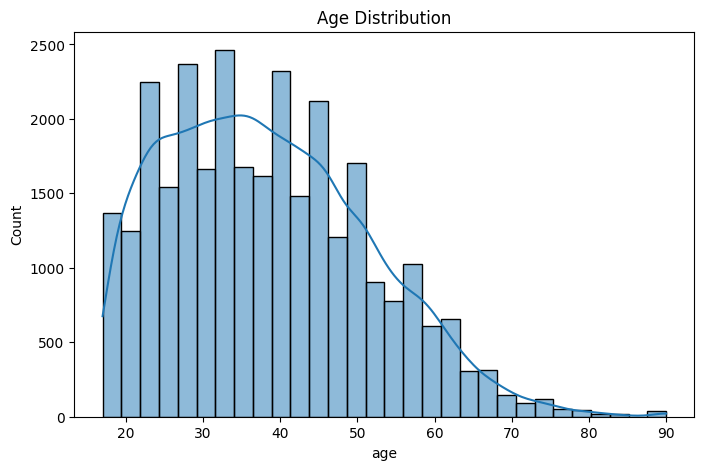

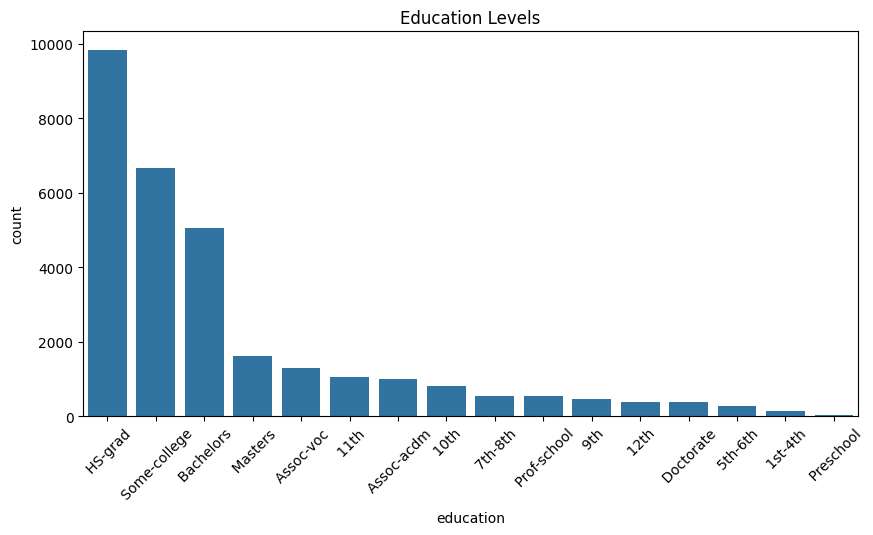

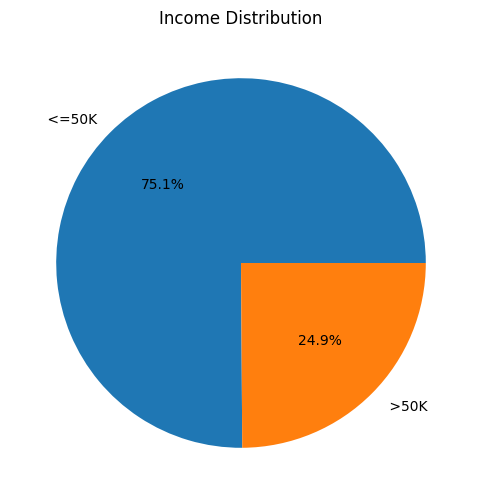

In [8]:
# Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Count plot for Education
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Education Levels")
plt.show()

# Pie chart for income
df['income'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), title="Income Distribution")
plt.ylabel('')
plt.show()


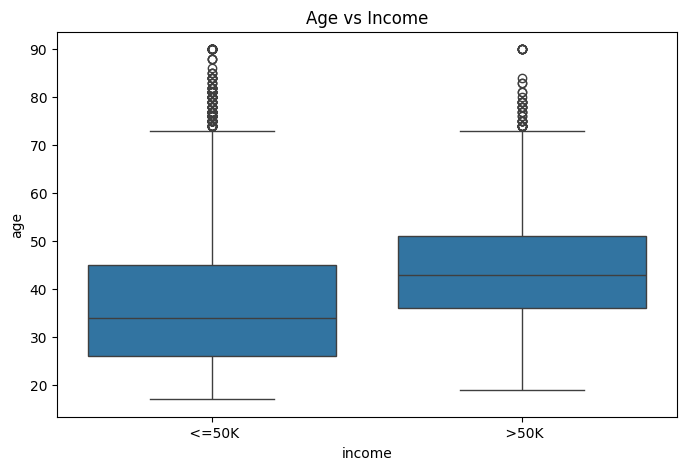

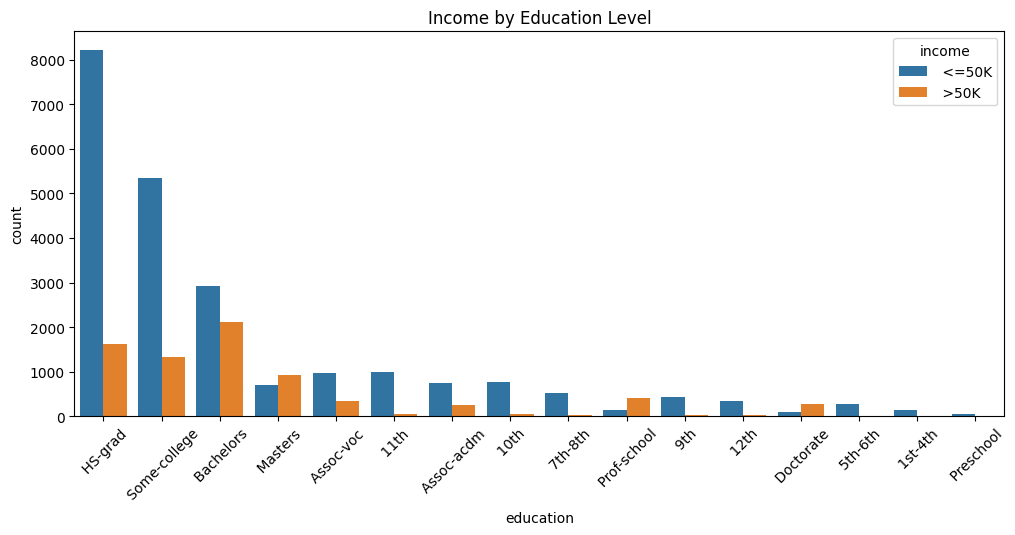

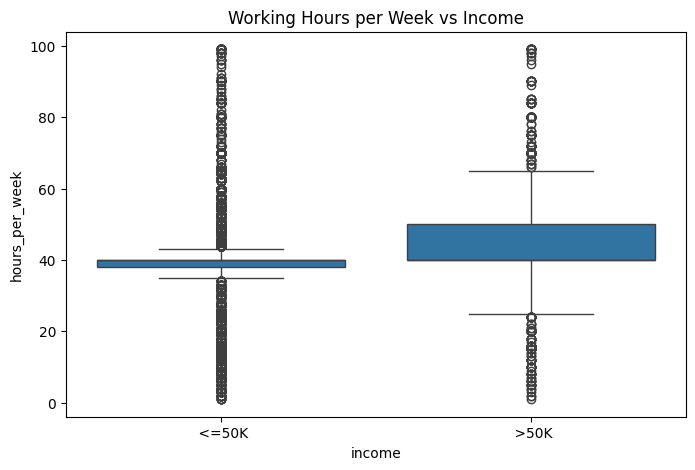

In [9]:
# Age vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='income', y='age', data=df)
plt.title("Age vs Income")
plt.show()

# Education vs Income
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='education', hue='income', order=df['education'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Income by Education Level")
plt.show()

# Hours per week vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours_per_week')
plt.title("Working Hours per Week vs Income")
plt.show()


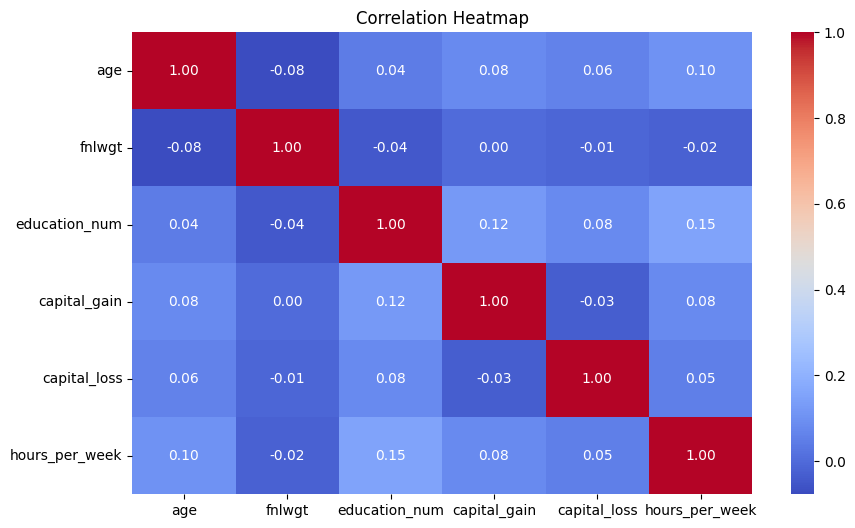

In [10]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()
